# LinkedIn Job Postings – Data Mining Notebook

Notebook tổng hợp cho đồ án *Khai phá dữ liệu* với 3 câu hỏi nghiên cứu:

- **RQ1:** Phân cụm nhóm nghề nghiệp dựa trên mô tả công việc.
- **RQ2:** Khai phá các *skill bundles* (nhóm kỹ năng thường đi cùng nhau).
- **RQ3:** Phân tích & dự đoán mức lương dựa trên thông tin công việc.


In [2]:
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, mean_squared_error
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

from mlxtend.preprocessing import TransactionEncoder
import networkx as nx
from networkx.algorithms.community import greedy_modularity_communities

plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['axes.grid'] = True
sns.set(style="whitegrid", font_scale=1.1)


In [3]:
def normalize_text(s: str) -> str:
    s = str(s).lower()
    s = re.sub(r"[^a-z0-9+# ]", " ", s)
    s = re.sub(r"\s+", " ", s).strip()
    return s

## 1. Load & Tổng quan dữ liệu

In [4]:
# Đặt đúng đường dẫn file trước khi chạy
JOB_POSTINGS_PATH = "data/postings.csv"
COMPANIES_PATH = "data/companies.csv"
EMP_COUNTS_PATH = "data/employee_counts.csv"
BENEFITS_PATH = "data/benefits.csv"  # có thể không dùng trong phân tích chính

job_df = pd.read_csv(JOB_POSTINGS_PATH)
companies_df = pd.read_csv(COMPANIES_PATH)
emp_counts_df = pd.read_csv(EMP_COUNTS_PATH)
try:
    benefits_df = pd.read_csv(BENEFITS_PATH)
except FileNotFoundError:
    benefits_df = None
    print("Không tìm thấy benefits.csv – bỏ qua bảng phúc lợi.")

job_df.head()

Không tìm thấy benefits.csv – bỏ qua bảng phúc lợi.


,job_id,company_name,title,description,max_salary,pay_period,location,company_id,views,med_salary,...,skills_desc,listed_time,posting_domain,sponsored,work_type,currency,compensation_type,normalized_salary,zip_code,fips
0,921716,Corcoran Sawyer Smith,Marketing Coordinator,Job descriptionA leading real estate firm in N...,20.0,HOURLY,"Princeton, NJ",2774458.0,20.0,NaN,...,Requirements: \n\nWe are seeking a College or ...,1.713398e+12,NaN,0,FULL_TIME,USD,BASE_SALARY,38480.0,8540.0,34021.0
1,1829192,NaN,Mental Health Therapist/Counselor,"At Aspen Therapy and Wellness , we are committ...",50.0,HOURLY,"Fort Collins, CO",NaN,1.0,NaN,...,NaN,1.712858e+12,NaN,0,FULL_TIME,USD,BASE_SALARY,83200.0,80521.0,8069.0
2,10998357,The National Exemplar,Assitant Restaurant Manager,The National Exemplar is accepting application...,65000.0,YEARLY,"Cincinnati, OH",64896719.0,8.0,NaN,...,We are currently accepting resumes for FOH - A...,1.713278e+12,NaN,0,FULL_TIME,USD,BASE_SALARY,55000.0,45202.0,39061.0
3,23221523,"Abrams Fensterman, LLP",Senior Elder Law / Trusts and Estates Associat...,Senior Associate Attorney - Elder Law / Trusts...,175000.0,YEARLY,"New Hyde Park, NY",766262.0,16.0,NaN,...,This position requires a baseline understandin...,1.712896e+12,NaN,0,FULL_TIME,USD,BASE_SALARY,157500.0,11040.0,36059.0
4,35982263,NaN,Service Technician,Looking for HVAC service tech with experience ...,80000.0,YEARLY,"Burlington, IA",NaN,3.0,NaN,...,NaN,1.713452e+12,NaN,0,FULL_TIME,USD,BASE_SALARY,70000.0,52601.0,19057.0


In [5]:
print("Số dòng job postings:", job_df.shape[0])
print("Số cột job postings:", job_df.shape[1])
print("Số công ty:", companies_df.shape[0])
print("Số bản ghi employee_counts:", emp_counts_df.shape[0])

print("\nThông tin kiểu dữ liệu của job_df:")
job_df.info()

# Thống kê mô tả nhanh cho một số cột số
display(job_df.describe(include=[np.number]).T.head(10))

Số dòng job postings: 123849
Số cột job postings: 31
Số công ty: 24473
Số bản ghi employee_counts: 35787

Thông tin kiểu dữ liệu của job_df:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 123849 entries, 0 to 123848
Data columns (total 31 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   job_id                      123849 non-null  int64  
 1   company_name                122130 non-null  object 
 2   title                       123849 non-null  object 
 3   description                 123842 non-null  object 
 4   max_salary                  29793 non-null   float64
 5   pay_period                  36073 non-null   object 
 6   location                    123849 non-null  object 
 7   company_id                  122132 non-null  float64
 8   views                       122160 non-null  float64
 9   med_salary                  6280 non-null    float64
 10  min_salary                  29793 non-null   fl

,count,mean,std,min,25%,50%,75%,max
job_id,123849.0,3.896402e+09,8.404355e+07,9.217160e+05,3.894587e+09,3.901998e+09,3.904707e+09,3.906267e+09
max_salary,29793.0,9.193942e+04,7.011101e+05,1.000000e+00,4.828000e+01,8.000000e+04,1.400000e+05,1.200000e+08
company_id,122132.0,1.220401e+07,2.554143e+07,1.009000e+03,1.435200e+04,2.269650e+05,8.047188e+06,1.034730e+08
views,122160.0,1.461825e+01,8.590360e+01,1.000000e+00,3.000000e+00,4.000000e+00,8.000000e+00,9.975000e+03
med_salary,6280.0,2.201562e+04,5.225587e+04,0.000000e+00,1.894000e+01,2.550000e+01,2.510500e+03,7.500000e+05
min_salary,29793.0,6.491085e+04,4.959738e+05,1.000000e+00,3.700000e+01,6.000000e+04,1.000000e+05,8.500000e+07
applies,23320.0,1.059198e+01,2.904739e+01,1.000000e+00,1.000000e+00,3.000000e+00,8.000000e+00,9.670000e+02
original_listed_time,123849.0,1.713152e+12,4.848209e+08,1.701811e+12,1.712863e+12,1.713395e+12,1.713478e+12,1.713573e+12
remote_allowed,15246.0,1.000000e+00,0.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00
expiry,123849.0,1.716213e+12,2.321394e+09,1.712903e+12,1.715481e+12,1.716042e+12,1.716088e+12,1.729125e+12


### 1.1. Tích hợp dữ liệu

In [6]:
# Merge job với thông tin công ty
job_merged = job_df.merge(companies_df, on="company_id", how="left")

# Sau khi merge, có thể xuất hiện description_x (job) và description_y (company)
# Chuẩn hóa lại để luôn có đúng một cột 'description' cho mô tả job
desc_cols = [c for c in job_merged.columns if "description" in c]
if "description" not in job_merged.columns:
    # Ưu tiên description_x nếu có (từ job_df)
    if "description_x" in job_merged.columns:
        job_merged["description"] = job_merged["description_x"]
    elif len(desc_cols) > 0:
        job_merged["description"] = job_merged[desc_cols[0]]
# Xóa các cột description trùng lặp khác (giữ lại 'description')
for c in desc_cols:
    if c != "description":
        job_merged.drop(columns=[c], inplace=True)

# Lấy bản ghi employee_count mới nhất cho mỗi công ty
emp_latest = emp_counts_df.sort_values("time_recorded").groupby("company_id").tail(1)
job_merged = job_merged.merge(
    emp_latest[["company_id", "employee_count", "follower_count"]],
    on="company_id",
    how="left"
)

print("Kích thước sau khi merge:", job_merged.shape)
job_merged.head()

Kích thước sau khi merge: (123849, 41)


,job_id,company_name,title,max_salary,pay_period,location,company_id,views,med_salary,min_salary,...,company_size,state,country,city,zip_code_y,address,url,description,employee_count,follower_count
0,921716,Corcoran Sawyer Smith,Marketing Coordinator,20.0,HOURLY,"Princeton, NJ",2774458.0,20.0,NaN,17.0,...,2.0,NJ,US,Jersey City,07302,242 Tenth Street,https://www.linkedin.com/company/corcoran-sawy...,Job descriptionA leading real estate firm in N...,402.0,2351.0
1,1829192,NaN,Mental Health Therapist/Counselor,50.0,HOURLY,"Fort Collins, CO",NaN,1.0,NaN,30.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"At Aspen Therapy and Wellness , we are committ...",NaN,NaN
2,10998357,The National Exemplar,Assitant Restaurant Manager,65000.0,YEARLY,"Cincinnati, OH",64896719.0,8.0,NaN,45000.0,...,1.0,Ohio,US,Mariemont,45227,6880 Wooster Pike,https://www.linkedin.com/company/the-national-...,The National Exemplar is accepting application...,15.0,40.0
3,23221523,"Abrams Fensterman, LLP",Senior Elder Law / Trusts and Estates Associat...,175000.0,YEARLY,"New Hyde Park, NY",766262.0,16.0,NaN,140000.0,...,2.0,New York,US,Lake Success,11042,3 Dakota Drive,https://www.linkedin.com/company/abrams-fenste...,Senior Associate Attorney - Elder Law / Trusts...,222.0,2427.0
4,35982263,NaN,Service Technician,80000.0,YEARLY,"Burlington, IA",NaN,3.0,NaN,60000.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Looking for HVAC service tech with experience ...,NaN,NaN


### 1.2. Bảng kỹ năng LinkedIn (job_skills.csv)

Trong phần này, nếu có file `job_skills.csv` và bảng mapping `skill_abr, skill_name`, ta sẽ load và gắn thêm danh sách kỹ năng LinkedIn cho từng job (cột `linkedin_skills`).

In [7]:
# 1.2 Load bảng kỹ năng LinkedIn (job_skills.csv) nếu có
JOB_SKILLS_PATH = "data/job_skills.csv"        # chỉnh lại đường dẫn cho đúng
SKILL_MAP_PATH = "data/skill_mapping.csv"      # file chứa cột: skill_abr, skill_name

try:
    job_skills_df = pd.read_csv(JOB_SKILLS_PATH)
    skill_map_df = pd.read_csv(SKILL_MAP_PATH)

    print("Kích thước job_skills_df:", job_skills_df.shape)
    print("Kích thước skill_map_df:", skill_map_df.shape)

    # Gộp để lấy tên kỹ năng đầy đủ
    job_skills_full = job_skills_df.merge(skill_map_df, on="skill_abr", how="left")

    # Gom danh sách kỹ năng theo từng job_id
    skills_per_job = (
        job_skills_full
        .dropna(subset=["skill_name"])
        .groupby("job_id")["skill_name"]
        .apply(list)
        .reset_index()
        .rename(columns={"skill_name": "linkedin_skills"})
    )

    # Merge vào job_merged
    job_merged = job_merged.merge(skills_per_job, on="job_id", how="left")
    print("Kích thước job_merged sau khi thêm linkedin_skills:", job_merged.shape)
    display(job_merged[["job_id", "title", "linkedin_skills"]].head())

except FileNotFoundError:
    job_skills_df = None
    skill_map_df = None
    print("Không tìm thấy job_skills.csv hoặc skill_mapping.csv – bỏ qua phần kỹ năng LinkedIn.")

Kích thước job_skills_df: (213768, 2)
Kích thước skill_map_df: (35, 2)
Kích thước job_merged sau khi thêm linkedin_skills: (123849, 42)


,job_id,title,linkedin_skills
0,921716,Marketing Coordinator,"[Marketing, Sales]"
1,1829192,Mental Health Therapist/Counselor,[Health Care Provider]
2,10998357,Assitant Restaurant Manager,"[Management, Manufacturing]"
3,23221523,Senior Elder Law / Trusts and Estates Associat...,[Other]
4,35982263,Service Technician,[Information Technology]


In [8]:
job_merged.columns

Index(['job_id', 'company_name', 'title', 'max_salary', 'pay_period',
       'location', 'company_id', 'views', 'med_salary', 'min_salary',
       'formatted_work_type', 'applies', 'original_listed_time',
       'remote_allowed', 'job_posting_url', 'application_url',
       'application_type', 'expiry', 'closed_time',
       'formatted_experience_level', 'skills_desc', 'listed_time',
       'posting_domain', 'sponsored', 'work_type', 'currency',
       'compensation_type', 'normalized_salary', 'zip_code_x', 'fips', 'name',
       'company_size', 'state', 'country', 'city', 'zip_code_y', 'address',
       'url', 'description', 'employee_count', 'follower_count',
       'linkedin_skills'],
      dtype='object')

## 2. EDA – Khám phá dữ liệu

Tỷ lệ missing (theo %):


med_salary                    94.93
remote_allowed                87.69
min_salary                    75.94
max_salary                    75.94
formatted_experience_level    23.75
company_size                   5.42
employee_count                 1.39
country                        1.39
description                    0.01
title                          0.00
location                       0.00
dtype: float64

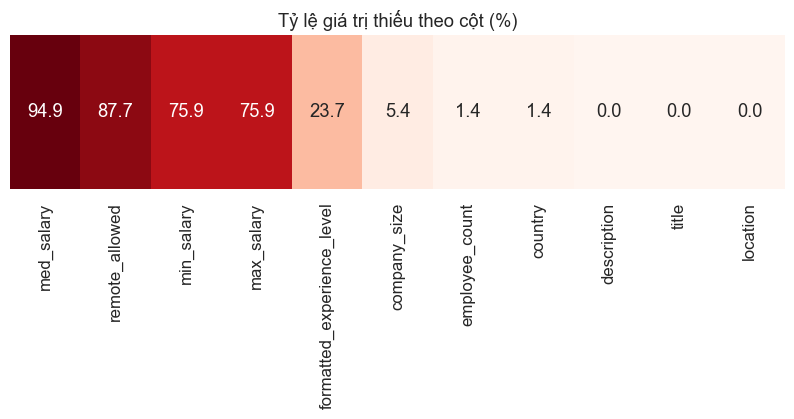

In [9]:
# 2.1 Tỷ lệ thiếu dữ liệu theo cột quan trọng
cols_check = [
    "title", "description", "min_salary", "med_salary", "max_salary",
    "formatted_experience_level", "remote_allowed", "location",
    "company_size", "employee_count", "country"
]

missing_ratio = job_merged[cols_check].isna().mean().sort_values(ascending=False)
print("Tỷ lệ missing (theo %):")
display((missing_ratio * 100).round(2))

# Vẽ heatmap tỷ lệ missing
plt.figure(figsize=(10, 2))
sns.heatmap(missing_ratio.to_frame().T * 100, annot=True, fmt=".1f",
            cmap="Reds", cbar=False)
plt.title("Tỷ lệ giá trị thiếu theo cột (%)")
plt.yticks([])
plt.show()

Số dòng có đủ min/med/max_salary: 0


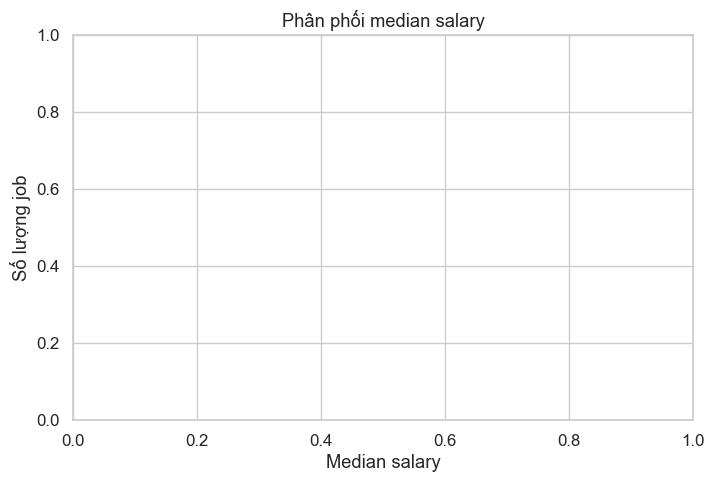

In [10]:
# 2.2 Phân phối median salary (chỉ các bản ghi có đủ thông tin)
salary_cols = ["min_salary", "med_salary", "max_salary"]
for c in salary_cols:
    job_merged[c] = pd.to_numeric(job_merged[c], errors="coerce")

salary_nonnull = job_merged[salary_cols].dropna()
print("Số dòng có đủ min/med/max_salary:", len(salary_nonnull))

plt.figure(figsize=(8,5))
sns.histplot(salary_nonnull["med_salary"], bins=40, kde=True, color="steelblue")
plt.xlabel("Median salary")
plt.ylabel("Số lượng job")
plt.title("Phân phối median salary")
plt.show()

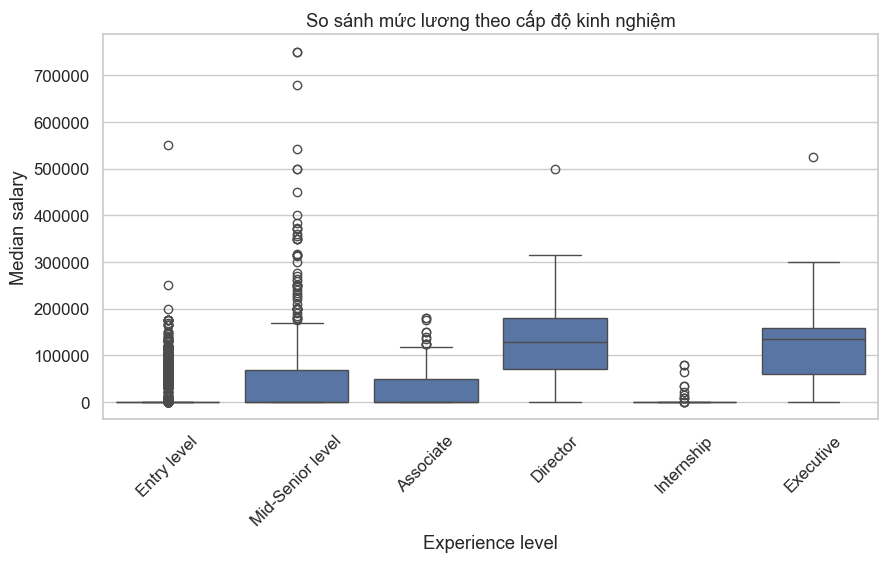

In [11]:
# 2.3 Boxplot median salary theo cấp độ kinh nghiệm
plt.figure(figsize=(10,5))
sns.boxplot(
    data=job_merged,
    x="formatted_experience_level",
    y="med_salary"
)
plt.xticks(rotation=45)
plt.xlabel("Experience level")
plt.ylabel("Median salary")
plt.title("So sánh mức lương theo cấp độ kinh nghiệm")
plt.show()

C:\Users\minh\AppData\Local\Temp\ipykernel_12096\4129249601.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_countries.values, y=top_countries.index, palette="viridis")


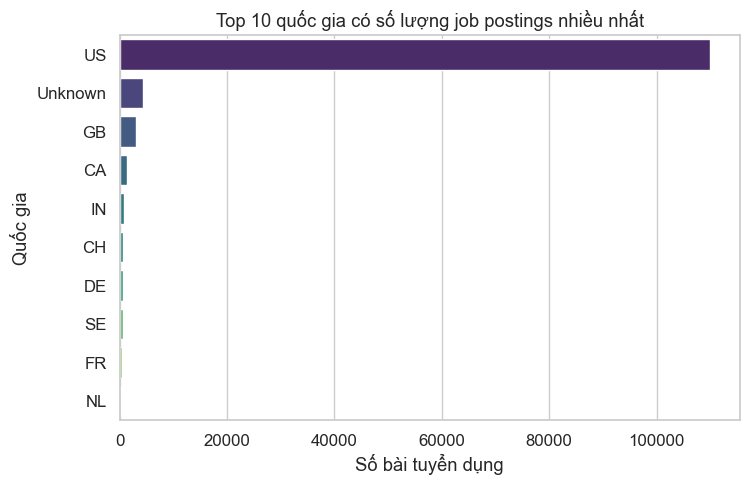

In [12]:
job_merged['country'].replace("0", np.nan, inplace=True)
job_merged['country'].fillna("Unknown", inplace=True)
# 2.4 Top quốc gia và thành phố có bài tuyển dụng nhiều nhất
top_countries = job_merged["country"].value_counts().head(10)
plt.figure(figsize=(8,5))
sns.barplot(x=top_countries.values, y=top_countries.index, palette="viridis")
plt.xlabel("Số bài tuyển dụng")
plt.ylabel("Quốc gia")
plt.title("Top 10 quốc gia có số lượng job postings nhiều nhất")
plt.show()


C:\Users\minh\AppData\Local\Temp\ipykernel_12096\3334227698.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_cities.values, y=top_cities.index, palette="magma")


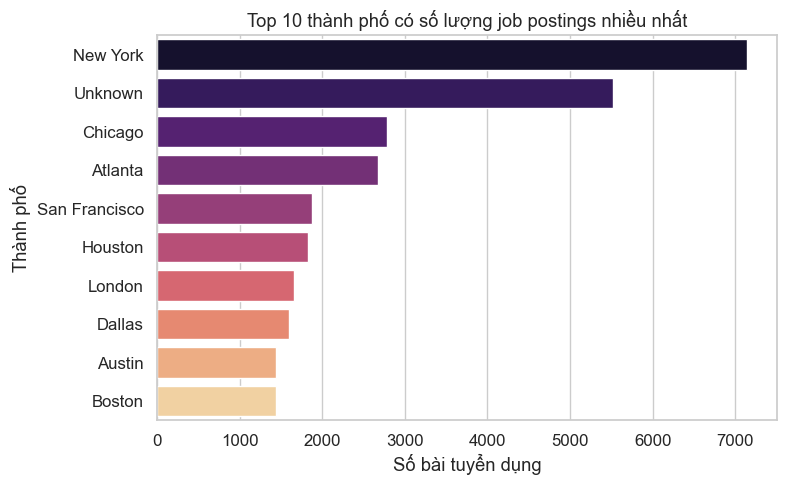

In [13]:

job_merged['city'].replace("0", np.nan, inplace=True)
job_merged['city'].fillna("Unknown", inplace=True)
top_cities = job_merged["city"].value_counts().head(10)
plt.figure(figsize=(8,5))
sns.barplot(x=top_cities.values, y=top_cities.index, palette="magma")
plt.xlabel("Số bài tuyển dụng")
plt.ylabel("Thành phố")
plt.title("Top 10 thành phố có số lượng job postings nhiều nhất")
plt.show()

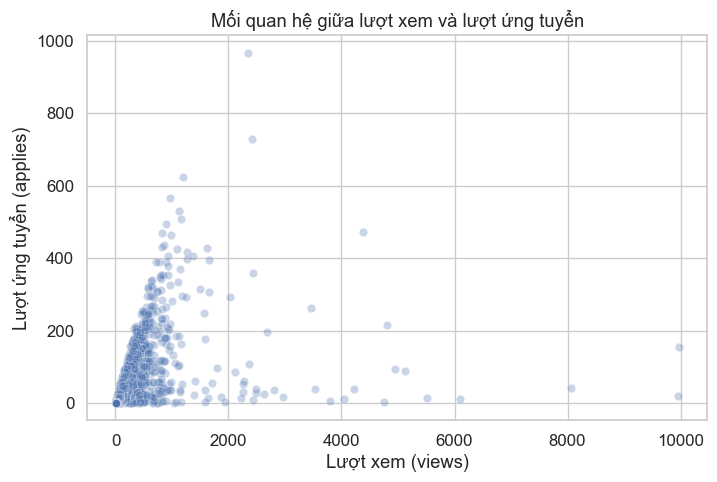

In [14]:
# 2.5 Mối quan hệ giữa lượt xem (views) và lượt ứng tuyển (applies)
plt.figure(figsize=(8,5))
sns.scatterplot(data=job_merged, x="views", y="applies", alpha=0.3)
plt.xlabel("Lượt xem (views)")
plt.ylabel("Lượt ứng tuyển (applies)")
plt.title("Mối quan hệ giữa lượt xem và lượt ứng tuyển")
plt.show()

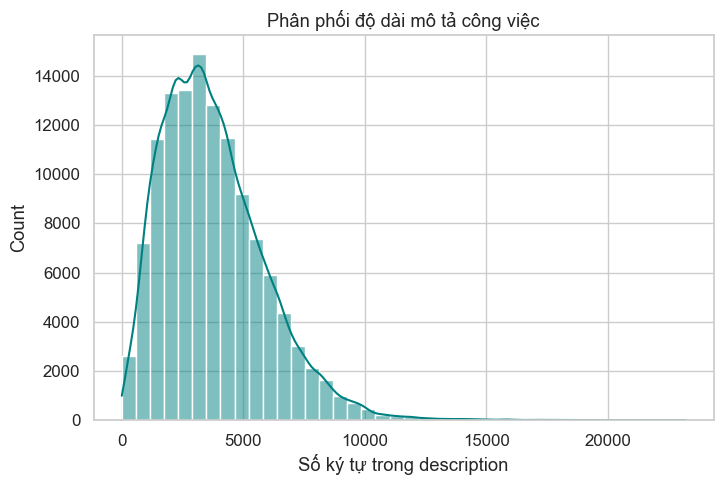

In [15]:
# 2.6 Phân phối độ dài mô tả công việc
job_merged["desc_len"] = job_merged["description"].fillna("").apply(lambda x: len(str(x)))

plt.figure(figsize=(8,5))
sns.histplot(job_merged["desc_len"], bins=40, kde=True, color="teal")
plt.xlabel("Số ký tự trong description")
plt.title("Phân phối độ dài mô tả công việc")
plt.show()

## 3. Phân tích bảng kỹ năng LinkedIn (job_skills.csv)

Phần này sử dụng `job_skills.csv` kết hợp bảng mapping `skill_abr → skill_name` để thống kê nhanh các nhóm kỹ năng mà LinkedIn gắn cho từng job. Đây là nguồn tham chiếu bổ sung bên cạnh kỹ năng trích xuất từ mô tả và ESCO.

Top 15 skill_abr:


skill_abr
IT      26137
SALE    22475
MGMT    20861
MNFC    18185
HCPR    17369
BD      14290
ENG     13009
OTHR    12608
FIN      8540
MRKT     5525
ACCT     5461
ADM      4860
CUST     4292
PRJM     3997
ANLS     3858
Name: count, dtype: int64

Top 15 skill_name:


skill_name
Information Technology    26137
Sales                     22475
Management                20861
Manufacturing             18185
Health Care Provider      17369
Business Development      14290
Engineering               13009
Other                     12608
Finance                    8540
Marketing                  5525
Accounting/Auditing        5461
Administrative             4860
Customer Service           4292
Project Management         3997
Analyst                    3858
Name: count, dtype: int64

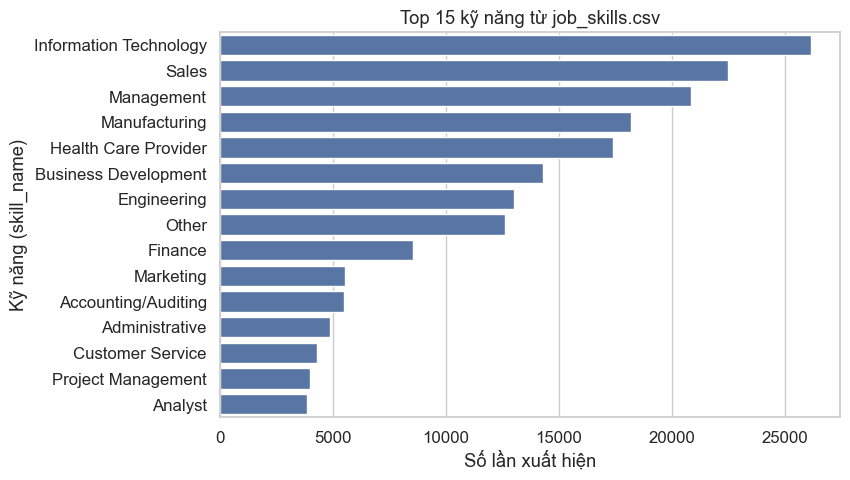

In [16]:
# Thống kê nhanh các kỹ năng từ job_skills.csv (nếu đã load được)
if 'job_skills_df' in globals() and job_skills_df is not None:
    # Đếm tần suất skill_abr
    print("Top 15 skill_abr:")
    display(job_skills_df["skill_abr"].value_counts().head(15))

    if 'skill_map_df' in globals() and skill_map_df is not None:
        skills_full = job_skills_df.merge(skill_map_df, on="skill_abr", how="left")
        print("Top 15 skill_name:")
        display(skills_full["skill_name"].value_counts().head(15))

        top_skill_names = skills_full["skill_name"].value_counts().head(15)
        plt.figure(figsize=(8,5))
        sns.barplot(x=top_skill_names.values, y=top_skill_names.index)
        plt.xlabel("Số lần xuất hiện")
        plt.ylabel("Kỹ năng (skill_name)")
        plt.title("Top 15 kỹ năng từ job_skills.csv")
        plt.show()
    else:
        print("Chưa có bảng skill_map_df – không xem được tên kỹ năng đầy đủ.")
else:
    print("Không có job_skills_df – bỏ qua phân tích job_skills.csv.")

## 3. RQ1 – Phân cụm nhóm nghề nghiệp dựa trên mô tả công việc

In [42]:
# # Lấy mẫu mô tả để phân cụm (tránh quá nặng)
# TEXT_COL = "description"
# job_text = job_merged[[TEXT_COL, "title"]].dropna(subset=[TEXT_COL]).copy()

# MAX_DOCS = 20000
# if len(job_text) > MAX_DOCS:
#     job_text_sample = job_text.sample(MAX_DOCS, random_state=42)
# else:
#     job_text_sample = job_text

# print("Số job dùng cho clustering:", len(job_text_sample))
TEXT_COL = "description"

# Giữ luôn job_id (và linkedin_skills nếu đã có) để join sau này
cols = ["job_id", "title", TEXT_COL]
if "linkedin_skills" in job_merged.columns:
    cols.append("linkedin_skills")

job_text = job_merged[cols].dropna(subset=[TEXT_COL]).copy()

MAX_DOCS = 20000
if len(job_text) > MAX_DOCS:
    job_text_sample = job_text.sample(MAX_DOCS, random_state=42)
else:
    job_text_sample = job_text

print("Số job dùng cho clustering:", len(job_text_sample))
job_text_sample.head()


Số job dùng cho clustering: 20000


,job_id,title,description,linkedin_skills
73457,3902931205,Warehouse,"Warehouse Associate\n\nSince 2022, Associated ...","[Management, Manufacturing]"
31563,3894855473,Influencer Talent Manager - Beauty,Interested in joining our influencer talent ma...,NaN
41620,3899525675,Talent Attraction Specialist,Talent Specialist - Hybrid Role Must be locate...,[Human Resources]
10762,3887106339,Retail Sales - Shoes - Stonebriar Centre,The ideal Salesperson is passionate about fash...,"[Sales, Customer Service]"
30334,3894555810,"Physician Assistant, Per Diem - Internal Medicine",1126363_RR00090444 Job ID: 1126363_RR00090444\...,[Other]


In [43]:
# TF-IDF vectorizer
tfidf = TfidfVectorizer(
    max_features=20000,
    ngram_range=(1,2),
    stop_words="english"
)
X_text = tfidf.fit_transform(job_text_sample[TEXT_COL])
X_text.shape

(20000, 20000)

In [44]:
# Thử nhiều số cụm và tính silhouette
sil_scores = {}
for k in [5, 8, 10, 12]:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_text)
    score = silhouette_score(X_text, labels)
    sil_scores[k] = score
    print(f"k={k}, silhouette={score:.3f}")

sil_scores

k=5, silhouette=0.009
k=8, silhouette=0.012
k=10, silhouette=0.014
k=12, silhouette=0.015


{5: 0.008633874621920778,
 8: 0.011979207383357147,
 10: 0.014430447979621652,
 12: 0.014774134169748595}

In [45]:
# Chọn số cụm (ví dụ: k có silhouette cao nhất)
best_k = max(sil_scores, key=sil_scores.get)
print("Chọn số cụm:", best_k)

kmeans = KMeans(n_clusters=best_k, random_state=42, n_init=10)
job_text_sample["cluster"] = kmeans.fit_predict(X_text)
# job_text_sample[["title", TEXT_COL, "cluster"]].head()
job_text_sample.head()

Chọn số cụm: 12


,job_id,title,description,linkedin_skills,cluster
73457,3902931205,Warehouse,"Warehouse Associate\n\nSince 2022, Associated ...","[Management, Manufacturing]",9
31563,3894855473,Influencer Talent Manager - Beauty,Interested in joining our influencer talent ma...,NaN,6
41620,3899525675,Talent Attraction Specialist,Talent Specialist - Hybrid Role Must be locate...,[Human Resources],5
10762,3887106339,Retail Sales - Shoes - Stonebriar Centre,The ideal Salesperson is passionate about fash...,"[Sales, Customer Service]",1
30334,3894555810,"Physician Assistant, Per Diem - Internal Medicine",1126363_RR00090444 Job ID: 1126363_RR00090444\...,[Other],3


In [46]:
# Xem top từ đặc trưng cho mỗi cụm
def top_terms_per_cluster(model, vectorizer, n_terms=15):
    terms = np.array(vectorizer.get_feature_names_out())
    order_centroids = model.cluster_centers_.argsort()[:, ::-1]
    cluster_terms = {}
    for i in range(model.n_clusters):
        top_terms = terms[order_centroids[i, :n_terms]]
        cluster_terms[i] = top_terms
    return cluster_terms

cluster_keywords = top_terms_per_cluster(kmeans, tfidf, n_terms=15)
cluster_keywords

{0: array(['students', 'student', 'school', 'learning', 'teaching',
        'university', 'academic', 'college', 'classroom', 'teacher',
        'teachers', 'education', 'faculty', 'district', 'curriculum'],
       dtype=object),
 1: array(['store', 'customer', 'sales', 'customers', 'merchandise', 'retail',
        'store manager', 'service', 'associates', 'customer service',
        'manager', 'work', 'company', 'team', 'experience'], dtype=object),
 2: array(['capital', 'wells fargo', 'fargo', 'wells', 'risk',
        'position posted', 'posted', 'financial', 'criminal', 'applicable',
        'status', 'experience', 'capitalone', 'capitalone com',
        'regarding criminal'], dtype=object),
 3: array(['care', 'patient', 'patients', 'nursing', 'health', 'nurse',
        'healthcare', 'medical', 'clinical', 'patient care', 'rn',
        'hospital', 'registered', 'registered nurse', 'practice'],
       dtype=object),
 4: array(['data', 'experience', 'design', 'engineering', 'software'

In [48]:
# Số lượng job trong mỗi cụm
job_text_sample["cluster"].value_counts().sort_index()

cluster
0      298
1     1262
2      152
3     2226
4     2670
5     3424
6      598
7     4391
8     1361
9     2179
10      96
11    1343
Name: count, dtype: int64

Số job có cả cluster và linkedin_skills: 19704


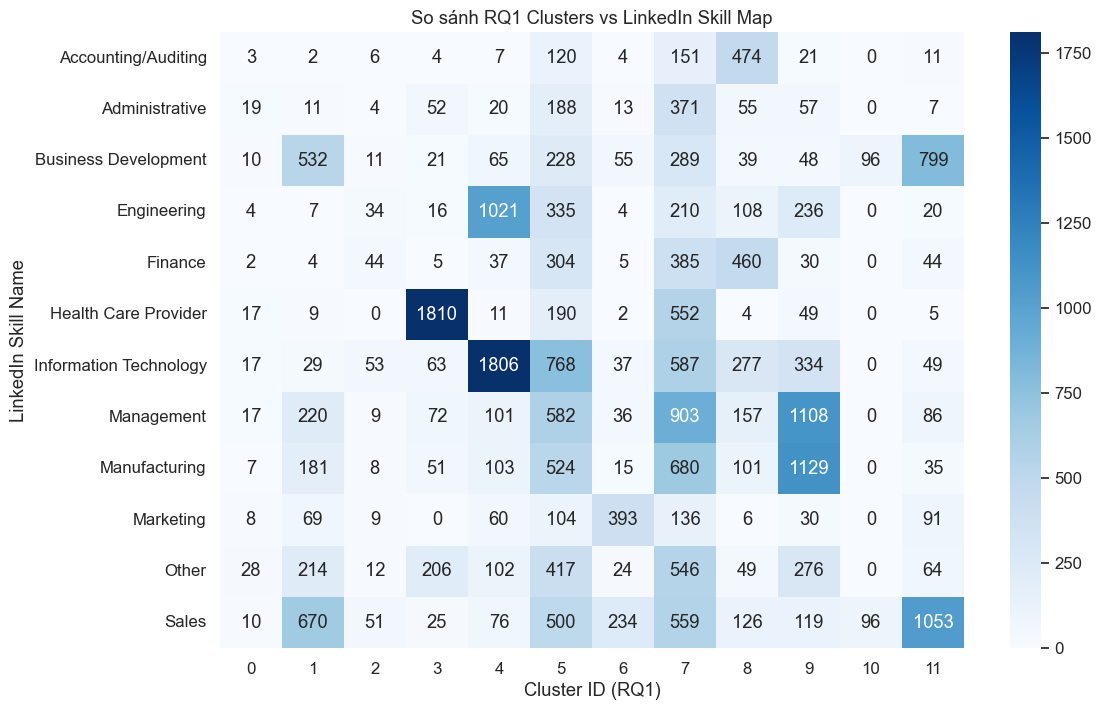

In [50]:
if "job_text_sample" not in globals() or "cluster" not in job_text_sample.columns:
    print("Chưa có job_text_sample hoặc cột 'cluster'. Hãy chạy lại phần KMeans (RQ1) sau khi chỉnh code lấy sample.")
elif "linkedin_skills" not in job_text_sample.columns:
    print("job_text_sample chưa có cột 'linkedin_skills'. Hãy chắc chắn đã merge linkedin_skills từ job_merged vào trước khi clustering.")
else:
    # Chỉ lấy job có linkedin_skills
    df = job_text_sample.dropna(subset=["linkedin_skills"]).copy()
    print("Số job có cả cluster và linkedin_skills:", len(df))

    rows = []
    for _, row in df.iterrows():
        c = row["cluster"]
        for skill in row["linkedin_skills"]:
            rows.append((c, skill))

    compare_df = pd.DataFrame(rows, columns=["cluster", "skill_name"])

    TOP_N = 12
    top_skills = compare_df["skill_name"].value_counts().head(TOP_N).index
    filtered_df = compare_df[compare_df["skill_name"].isin(top_skills)]

    pivot = filtered_df.pivot_table(
        index="skill_name",
        columns="cluster",
        aggfunc="size",
        fill_value=0
    )

    plt.figure(figsize=(12, 8))
    sns.heatmap(pivot, annot=True, fmt="d", cmap="Blues")
    plt.title("So sánh RQ1 Clusters vs LinkedIn Skill Map")
    plt.xlabel("Cluster ID (RQ1)")
    plt.ylabel("LinkedIn Skill Name")
    plt.show()


## 4. RQ2 – Khai phá *Skill Bundles* từ ESCO Ontology

In [23]:
# ==== 4.1. Load & làm sạch ESCO skills (skill.csv) ====
# Đảm bảo skill.csv (từ ESCO classification/en/csv) nằm cùng thư mục notebook

ESCO_SKILL_PATH = "data/skills_en.csv"
esco = pd.read_csv(ESCO_SKILL_PATH)
esco_raw = esco["preferredLabel"].dropna().astype(str)
esco_norm = esco_raw.apply(normalize_text)

def is_valid_skill(term: str) -> bool:
    term = term.strip()
    if len(term) < 3:
        return False
    if term.isdigit():
        return False
    if len(term.split()) > 5:
        return False
    return True

esco_clean = esco_norm[esco_norm.apply(is_valid_skill)].drop_duplicates()
esco_skills = esco_clean.tolist()
print("Số ESCO skills sau khi làm sạch:", len(esco_skills))
esco_skills[:20]

Số ESCO skills sau khi làm sạch: 12280


['manage musical staff',
 'supervise correctional procedures',
 'apply anti oppressive practices',
 'identify available services',
 'perform toxicological studies',
 'ensure coquille uniformity',
 'haskell',
 'show initiative',
 'apply diplomatic principles',
 'lead police investigations',
 'handle fish harvesting waste',
 'develop energy saving concepts',
 'work with soloists',
 'sport and exercise medicine',
 'conduct research on flora',
 'install heat pump',
 'design biomass installations',
 'handle equipment while suspended',
 'teach housekeeping skills',
 'check train engines']

In [24]:
# ==== 4.2. Vector hóa n-gram từ mô tả công việc ====
desc_series_full = job_merged["description"].fillna("").apply(normalize_text)

MAX_ROWS_NGRAM = 80000
if len(desc_series_full) > MAX_ROWS_NGRAM:
    desc_sample = desc_series_full.sample(MAX_ROWS_NGRAM, random_state=42)
else:
    desc_sample = desc_series_full

vec_all = CountVectorizer(
    ngram_range=(1,4),
    min_df=15,
    max_df=0.85,
    token_pattern=r"[a-z0-9+#]+",
    stop_words="english"
)
vec_all.fit(desc_sample)
ngrams_all = set(vec_all.get_feature_names_out())
print("Tổng số n-gram từ mô tả:", len(ngrams_all))

Tổng số n-gram từ mô tả: 643067


In [25]:
# ==== 4.3. Giao giữa ESCO skills & n-gram trong dữ liệu ====
esco_set = set(esco_skills)
skill_vocab = sorted(list(esco_set & ngrams_all))
print("Số ESCO skills thực sự xuất hiện trong corpus:", len(skill_vocab))
skill_vocab[:30]

Số ESCO skills thực sự xuất hiện trong corpus: 751


['abap',
 'accounting',
 'accounting entries',
 'achieve sales targets',
 'acoustics',
 'actuarial science',
 'acute care',
 'adhesives',
 'adjust priorities',
 'adobe creative suite',
 'adobe illustrator',
 'adobe photoshop',
 'adult education',
 'advanced materials',
 'advocate health',
 'aerospace engineering',
 'aesthetics',
 'agile development',
 'agile project management',
 'agronomy',
 'ajax',
 'alarm systems',
 'algebra',
 'algorithms',
 'allergies',
 'alternative energy',
 'analytical chemistry',
 'angular',
 'animal nutrition',
 'animal welfare']

In [26]:
# ==== 4.4. Ma trận doc x skill cho toàn bộ job ====
vec_skill = CountVectorizer(
    vocabulary=skill_vocab,
    ngram_range=(1,4),
    binary=True,
    token_pattern=r"[a-z0-9+#]+"
)
X_skill = vec_skill.fit_transform(desc_series_full)
skill_names = np.array(vec_skill.get_feature_names_out())
print("Ma trận doc x skill:", X_skill.shape)

Ma trận doc x skill: (123849, 751)


In [27]:
# Tạo skills_list cho từng job
skills_list = []
for i in range(X_skill.shape[0]):
    idx = X_skill[i].nonzero()[1]
    skills = skill_names[idx].tolist()
    skills_list.append(skills)

job_merged["skills_list"] = skills_list
job_merged[["title", "skills_list"]].head(10)

,title,skills_list
0,Marketing Coordinator,"[genetics, graphic design, plan]"
1,Mental Health Therapist/Counselor,"[communication, crisis intervention, plan]"
2,Assitant Restaurant Manager,[]
3,Senior Elder Law / Trusts and Estates Associat...,[communication]
4,Service Technician,[]
5,Economic Development and Planning Intern,"[communication, economics, geography, public a..."
6,Producer,[motion graphics]
7,Building Engineer,"[building codes, communication, english, plan,..."
8,Respiratory Therapist,"[chemistry, control systems, plan, respiratory..."
9,Worship Leader,[team building]


In [28]:
# ==== 4.5. Tính co-occurrence & lift ====
skills_transactions = job_merged["skills_list"]
skills_transactions = skills_transactions[skills_transactions.map(len) > 0]
print("Số job có ít nhất 1 skill ESCO:", len(skills_transactions))

te = TransactionEncoder()
te_ary = te.fit(skills_transactions.tolist()).transform(skills_transactions.tolist())
skills_ohe = pd.DataFrame(te_ary, columns=te.columns_)

X_bin = skills_ohe.values
N = X_bin.shape[0]

support = X_bin.mean(axis=0)
co_matrix = (X_bin.T @ X_bin) / N

skills = skills_ohe.columns.tolist()
pairs = []
for i in range(len(skills)):
    for j in range(i+1, len(skills)):
        supp_ij = co_matrix[i, j]
        if supp_ij == 0:
            continue
        supp_i = support[i]
        supp_j = support[j]
        conf = supp_ij / supp_i if supp_i > 0 else 0
        lift = conf / supp_j if supp_j > 0 else 0
        pairs.append({
            "skill_A": skills[i],
            "skill_B": skills[j],
            "support_AB": supp_ij,
            "support_A": supp_i,
            "support_B": supp_j,
            "confidence": conf,
            "lift": lift
        })

rules_esco = pd.DataFrame(pairs).sort_values("lift", ascending=False)
rules_esco.head(20)

Số job có ít nhất 1 skill ESCO: 114796


,skill_A,skill_B,support_AB,support_A,support_B,confidence,lift
20407,control production,schedule production,0.000009,0.000122,0.000122,0.071429,585.693878
34494,financial engineering,satisfy customers,0.000009,0.000253,0.000070,0.034483,494.810345
33992,evaluate employees,food service operations,0.000009,0.000070,0.000270,0.125000,462.887097
10601,building materials industry,prospect new customers,0.000009,0.000200,0.000105,0.043478,415.927536
40425,identify customer requirements,marketing mix,0.000009,0.000087,0.000244,0.100000,409.985714
11847,business management principles,prepare financial statements,0.000009,0.000044,0.000679,0.200000,294.348718
11851,business management principles,thermodynamics,0.000009,0.000044,0.000723,0.200000,276.616867
13687,chemical processes,control production,0.000009,0.000261,0.000122,0.033333,273.323810
9984,build networks,marine engineering,0.000009,0.000157,0.000209,0.055556,265.731481
20409,control production,smed,0.000009,0.000122,0.000296,0.071429,241.168067


In [29]:
# ==== 4.6. Xây network graph skill bundles ====
TOP_EDGES = 60
top_rules = rules_esco.head(TOP_EDGES)

G = nx.Graph()
for _, r in top_rules.iterrows():
    G.add_edge(r["skill_A"], r["skill_B"], weight=r["lift"])

print("Nodes:", G.number_of_nodes(), "Edges:", G.number_of_edges())

communities = list(greedy_modularity_communities(G))
print("Số community:", len(communities))
for i, comm in enumerate(communities):
    print(f"Community {i} size={len(comm)} sample={list(comm)[:10]}")

Nodes: 78 Edges: 60
Số community: 21
Community 0 size=12 sample=['product data management', 'pesticides', 'irrigation systems', 'herbicides', 'conserve natural resources', 'control engineering', 'smed', 'coach employees', 'water consumption', 'schedule production']
Community 1 size=7 sample=['biomechanics', 'test hardware', 'composite materials', 'mechanical tools', 'wire harnesses', 'orthotics', 'sustainable manufacturing']
Community 2 size=6 sample=['maintain laboratory equipment', 'write technical reports', 'collect samples', 'energy transformation', 'medical laboratory technology', 'organic chemistry']
Community 3 size=6 sample=['handle customer complaints', 'process customer orders', 'handle complaints', 'assess customers', 'education law', 'listen actively']
Community 4 size=6 sample=['epidemiology', 'dietetics', 'evaluate employees', 'trigonometry', 'food service operations', 'audiology']
Community 5 size=5 sample=['environmental design', 'collection management', 'power engineer

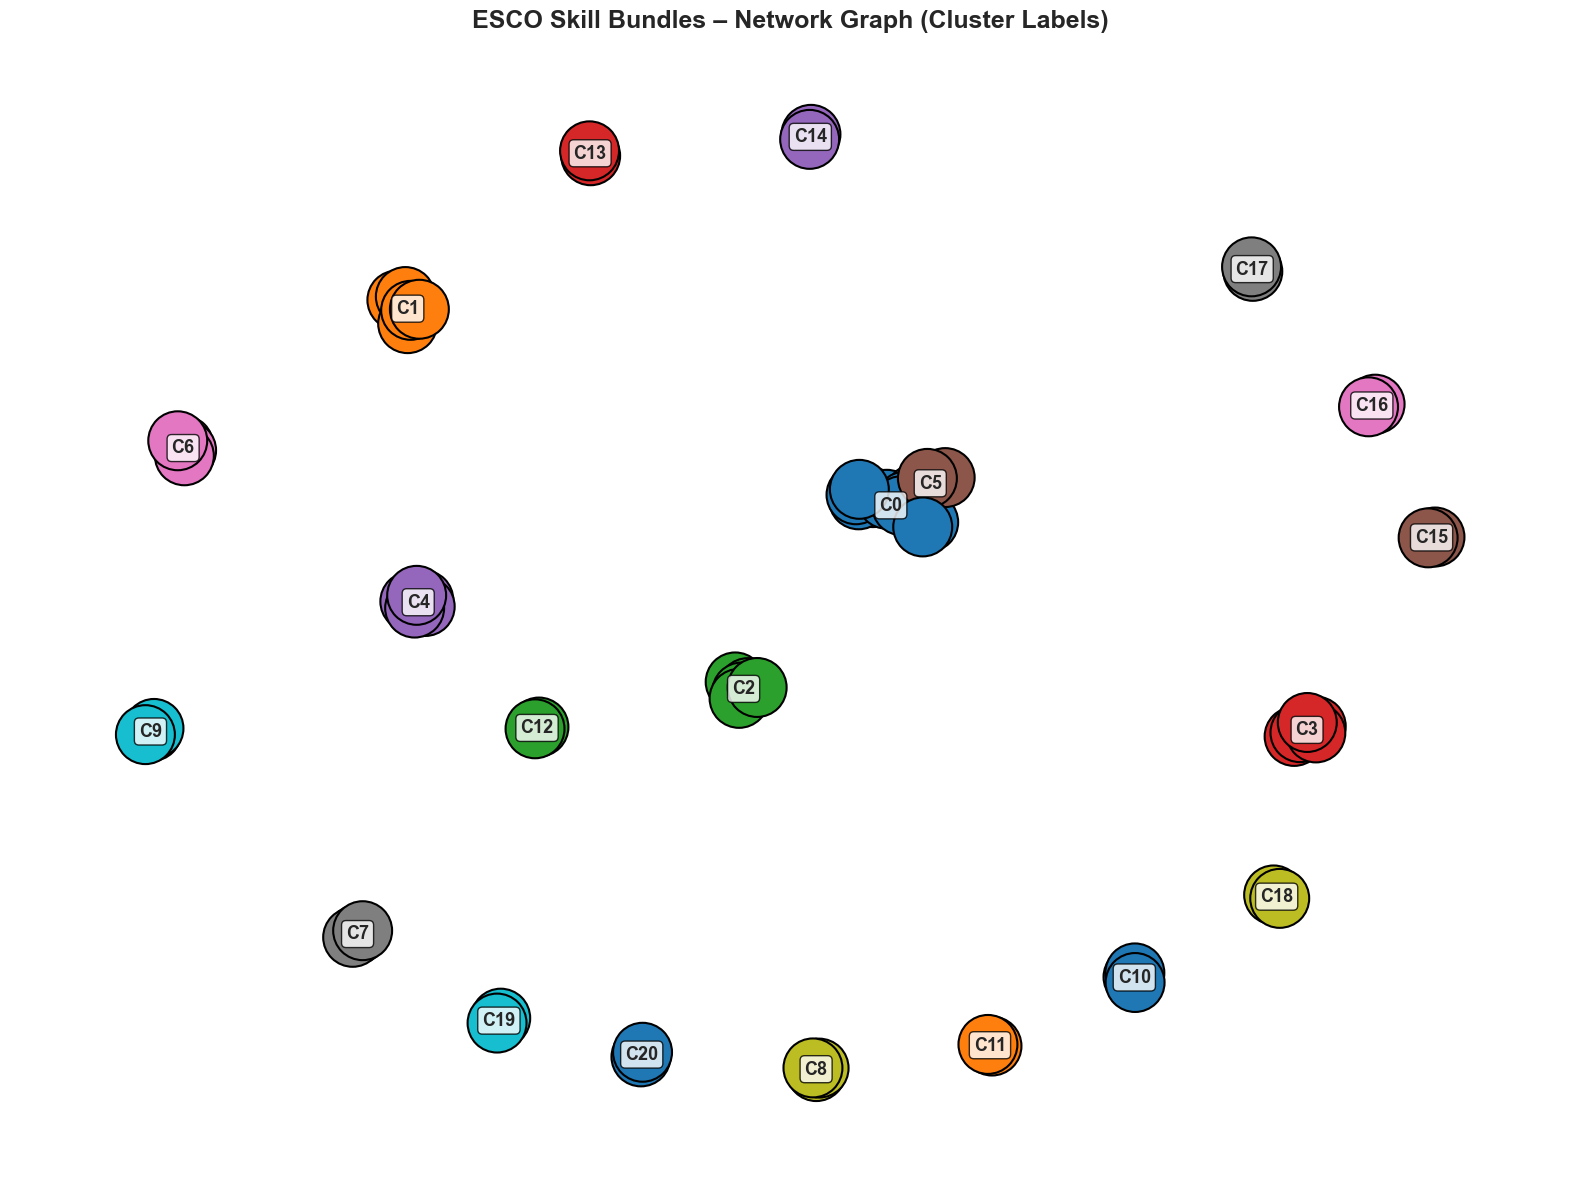

In [30]:
# Vẽ network graph với màu theo community + viền + 1 label cho mỗi cụm

node2comm = {}
for cid, comm in enumerate(communities):
    for n in comm:
        node2comm[n] = cid

cmap = plt.get_cmap("tab10")
node_colors = [cmap(node2comm[n] % 10) for n in G.nodes()]

# Layout
pos = nx.spring_layout(G, k=1.3, iterations=500, seed=42)

plt.figure(figsize=(16, 12))

# Edge weights
edges = G.edges(data=True)
weights = np.array([d["weight"] for (_, _, d) in edges])
if len(weights) > 0:
    min_w, max_w = weights.min(), weights.max()
    if max_w > min_w:
        norm_w = 1 + 4 * (weights - min_w) / (max_w - min_w)
    else:
        norm_w = np.ones_like(weights)
else:
    norm_w = []

# Vẽ edges
nx.draw_networkx_edges(
    G, pos,
    edge_color="lightgray",
    width=norm_w,
    alpha=0.7
)

# Vẽ nodes (có viền)
nx.draw_networkx_nodes(
    G, pos,
    node_color=node_colors,
    node_size=1800,
    edgecolors="black",
    linewidths=1.5
)

# ======= LABEL CHO MỖI CỤM =======
# Tính tâm (mean) vị trí các node trong từng cụm
import numpy as np

cluster_centers = {}
for cid, comm in enumerate(communities):
    xs = [pos[n][0] for n in comm]
    ys = [pos[n][1] for n in comm]
    cluster_centers[cid] = (np.mean(xs), np.mean(ys))

# Vẽ 1 label tại tâm cụm
for cid, (x, y) in cluster_centers.items():
    plt.text(
        x, y,
        f"C{cid}",
        fontsize=13,
        fontweight="bold",
        ha="center",
        va="center",
        bbox=dict(boxstyle="round,pad=0.25", fc="white", ec="black", alpha=0.8)
    )

plt.title("ESCO Skill Bundles – Network Graph (Cluster Labels)", fontsize=18, fontweight="bold")
plt.axis("off")
plt.tight_layout()
plt.show()


In [31]:
def plot_community(G, community, cid):
    subG = G.subgraph(list(community))

    pos = nx.spring_layout(subG, k=1.2, iterations=400, seed=42)
    plt.figure(figsize=(16, 12))

    nx.draw_networkx_nodes(subG, pos, 
                           node_size=2400, 
                           node_color="#4A90E2",
                           edgecolors="black")

    nx.draw_networkx_edges(subG, pos, width=2, alpha=0.7, edge_color="gray")

    nx.draw_networkx_labels(subG, pos, font_size=11, font_weight="bold")

    plt.title(f"Skill Bundle Cluster {cid}", fontsize=16)
    plt.axis("off")
    plt.show()


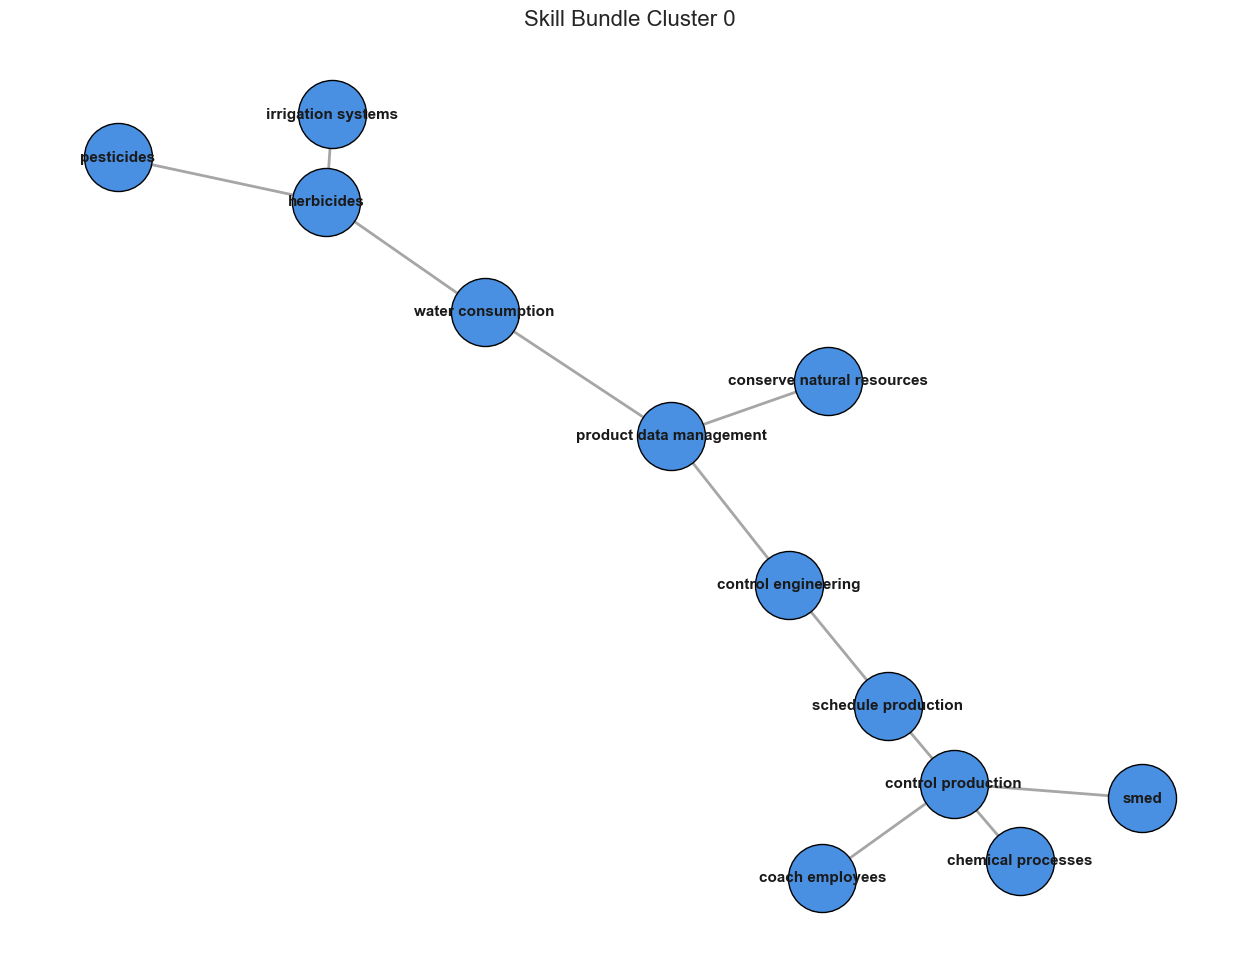

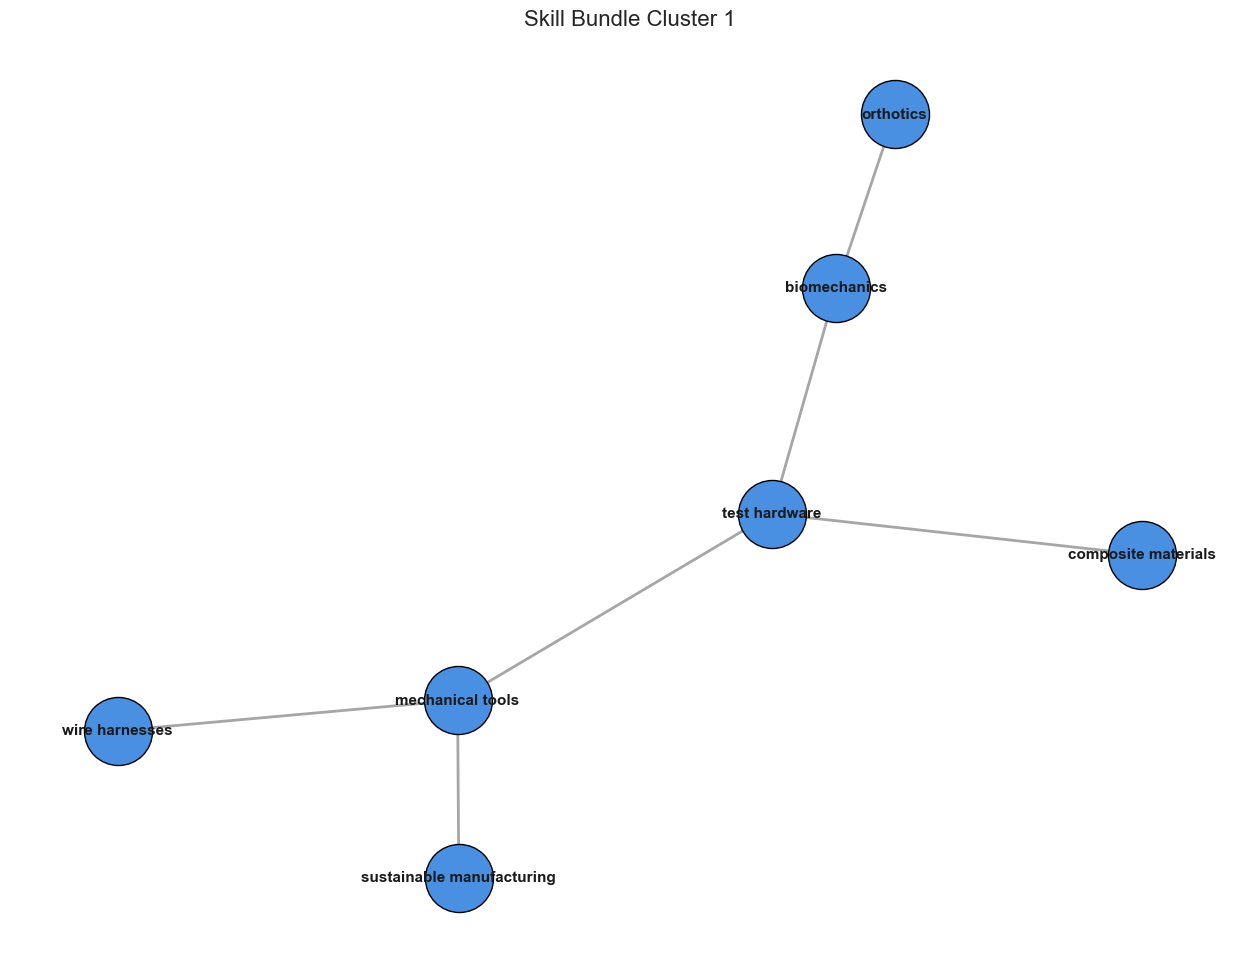

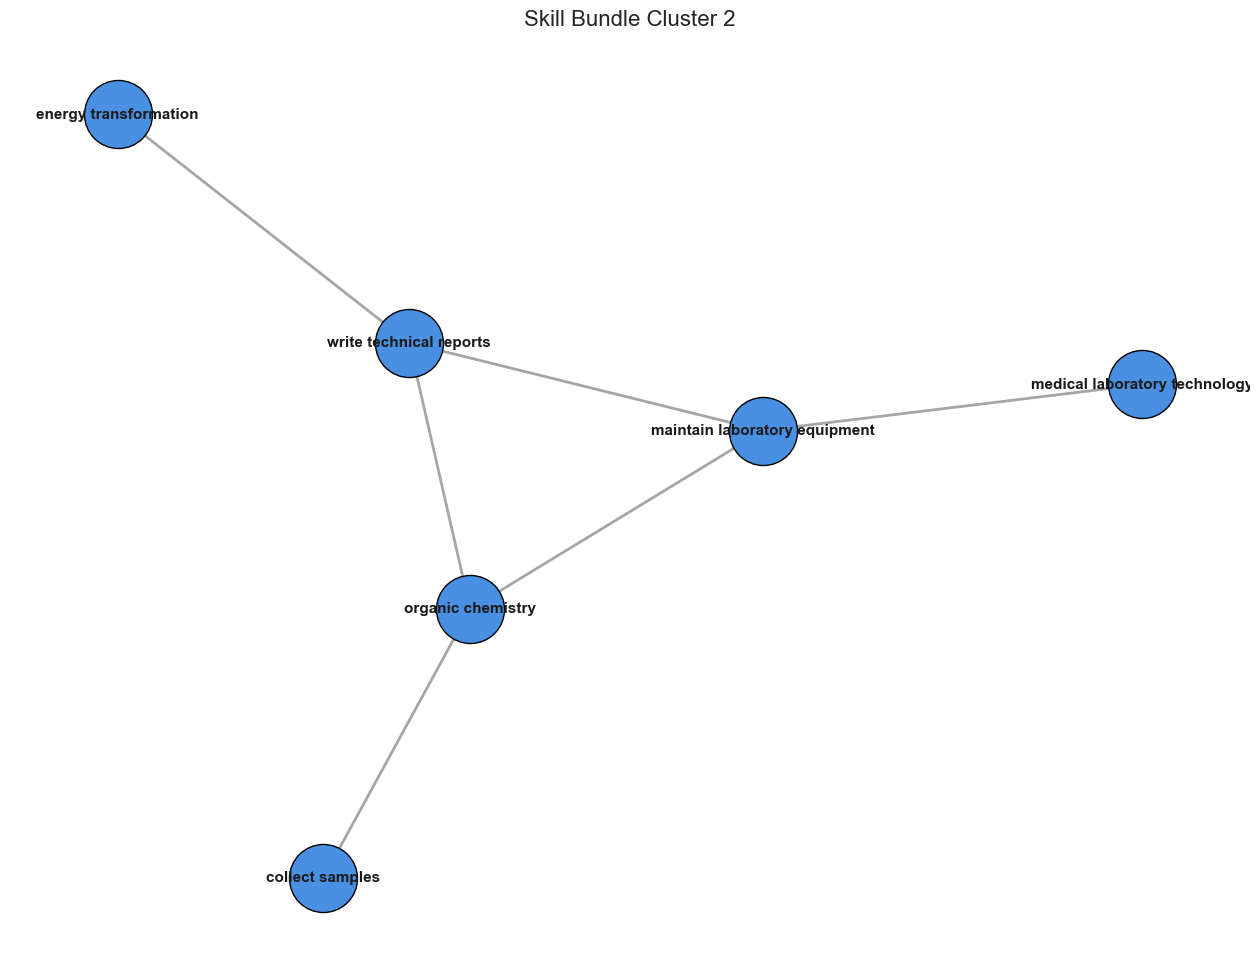

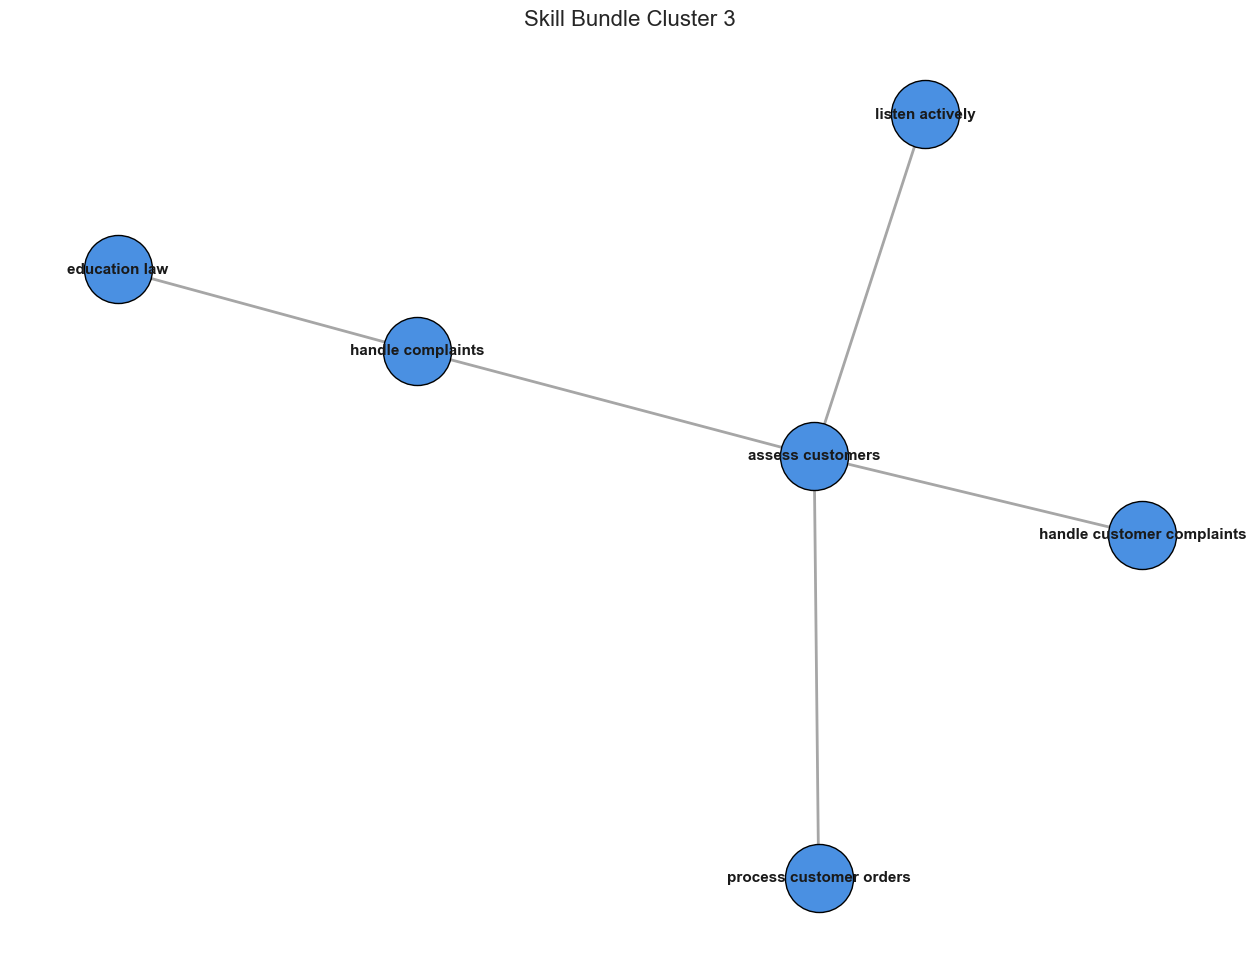

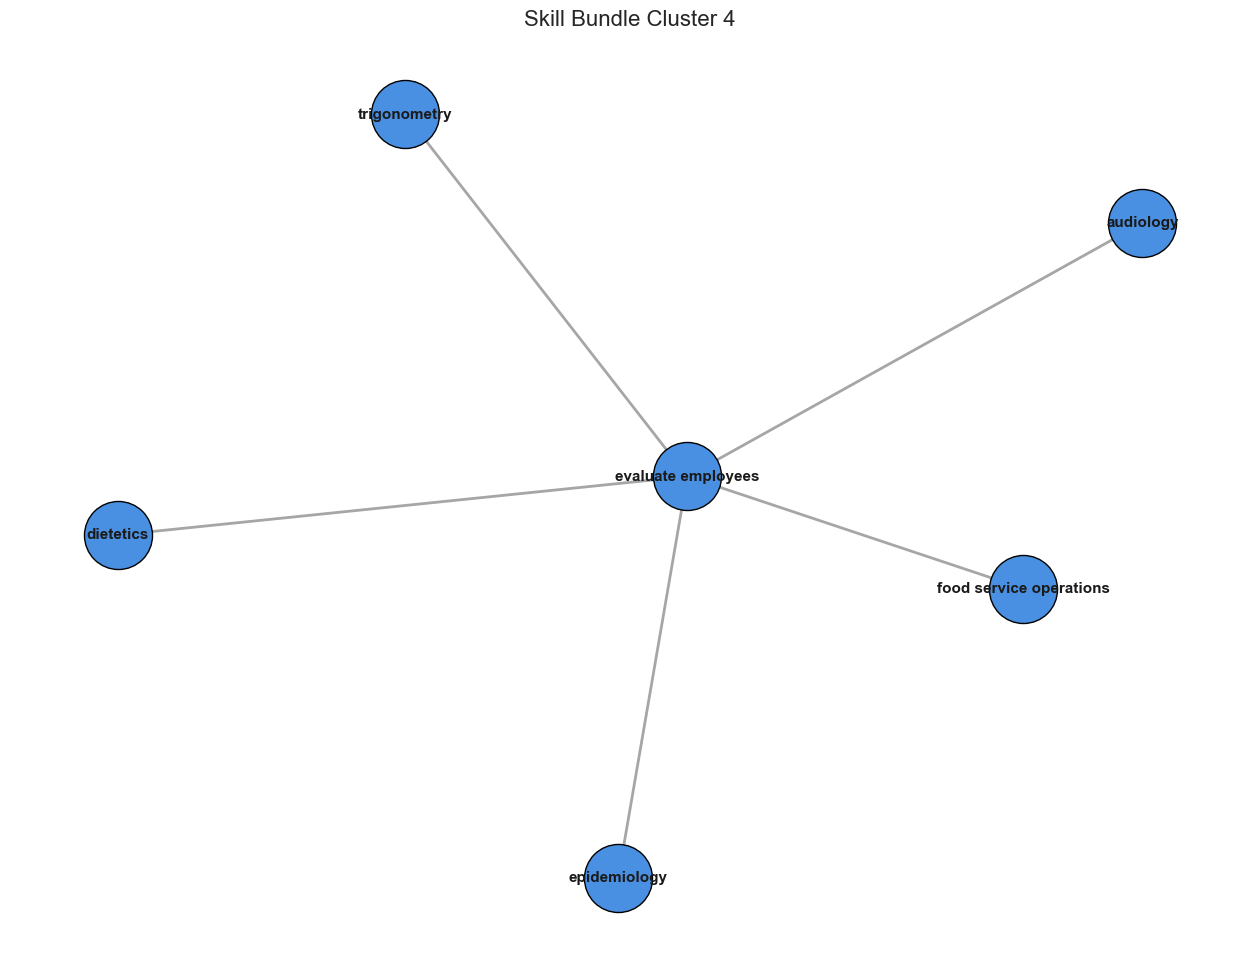

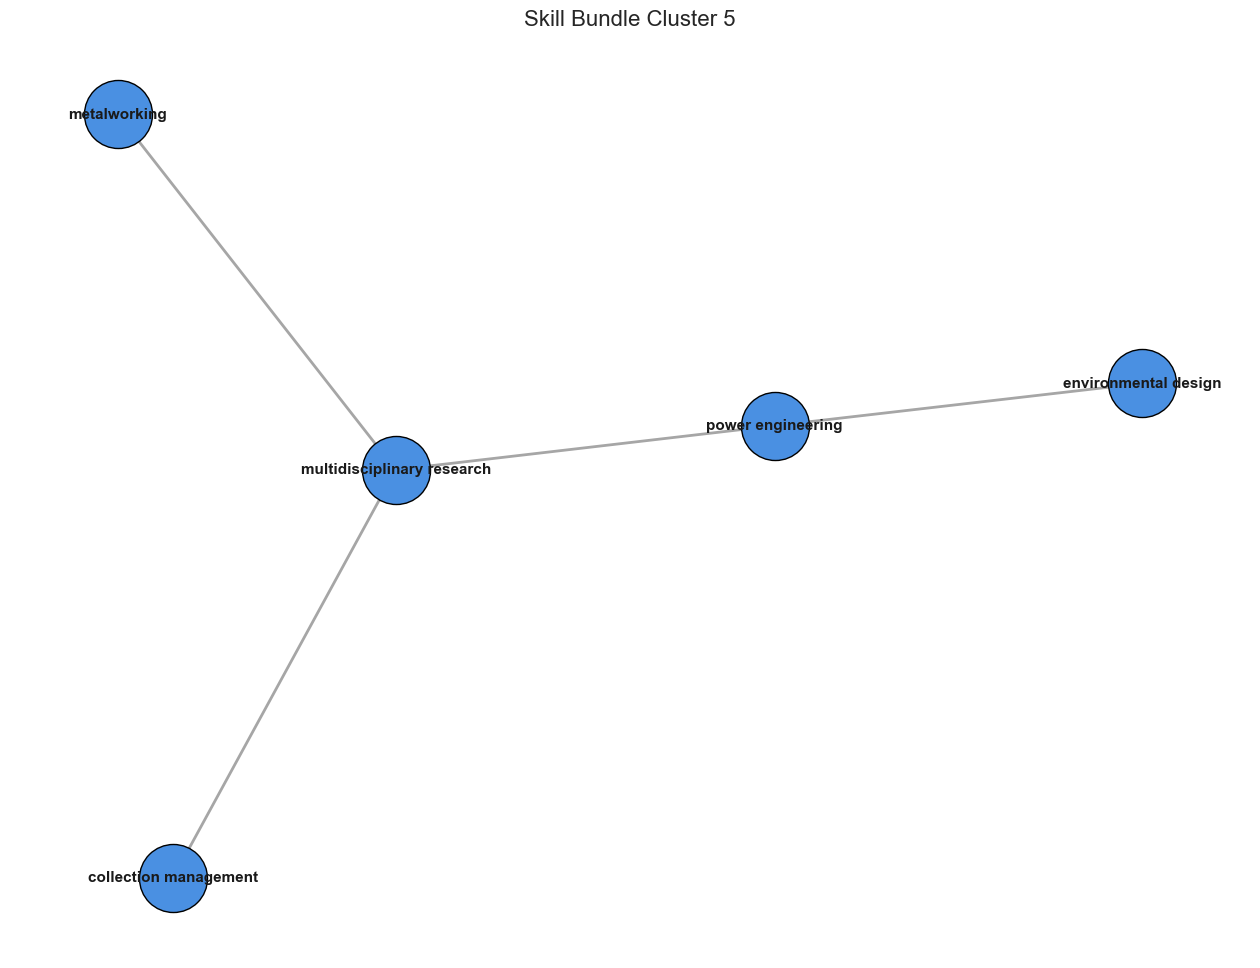

In [32]:
for cid, comm in enumerate(communities[:6]):
    plot_community(G, comm, cid)


## 5. RQ3 – Phân tích & dự đoán lương

In [51]:
job_merged.columns

Index(['job_id', 'company_name', 'title', 'max_salary', 'pay_period',
       'location', 'company_id', 'views', 'med_salary', 'min_salary',
       'formatted_work_type', 'applies', 'original_listed_time',
       'remote_allowed', 'job_posting_url', 'application_url',
       'application_type', 'expiry', 'closed_time',
       'formatted_experience_level', 'skills_desc', 'listed_time',
       'posting_domain', 'sponsored', 'work_type', 'currency',
       'compensation_type', 'normalized_salary', 'zip_code_x', 'fips', 'name',
       'company_size', 'state', 'country', 'city', 'zip_code_y', 'address',
       'url', 'description', 'employee_count', 'follower_count',
       'linkedin_skills', 'desc_len', 'skills_list'],
      dtype='object')

In [52]:
# RQ3 – Dự đoán lương với feature engineering

df = job_merged.copy()

# Giữ lại các job có thông tin med_salary hợp lệ
df = df[~df["med_salary"].isna()].copy()
df = df[df["med_salary"] > 0].copy()

print("Số job có med_salary:", len(df))


Số job có med_salary: 6266


In [53]:
# Loại bỏ outlier cực lớn (1% thấp nhất, 1% cao nhất)
q1, q99 = df["med_salary"].quantile([0.01, 0.99])
df = df[(df["med_salary"] >= q1) & (df["med_salary"] <= q99)].copy()

print("Sau khi loại outlier:", len(df))

# Log-transform salary (dự đoán trên thang log)
df["log_salary"] = np.log1p(df["med_salary"])


Sau khi loại outlier: 6147


In [54]:
# 1) Độ dài mô tả (nếu chưa có)
if "desc_len" not in df.columns:
    df["desc_len"] = df["description"].fillna("").astype(str).str.len()

# 2) Seniority từ title
df["seniority"] = (
    df["title"]
    .fillna("")
    .str.lower()
    .str.extract(r"(senior|junior|lead|manager|director)", expand=False)
)
df["seniority"] = df["seniority"].fillna("normal")

# 3) Số lượng kỹ năng từ ESCO (skills_list)
def count_list(x):
    if isinstance(x, list):
        return len(x)
    return 0

df["num_skills"] = df["skills_list"].apply(count_list)

# 4) Số lượng kỹ năng LinkedIn (linkedin_skills)
df["num_linkedin_skills"] = df["linkedin_skills"].apply(count_list)

# 5) Median salary trung bình theo country (context địa lý)
df["country_mean_salary"] = (
    df.groupby("country")["med_salary"].transform("mean")
)

# 6) Tỉ lệ apply / view (đo mức hấp dẫn của job)
df["apply_rate"] = df["applies"] / (df["views"] + 1)

# 7) Nếu đã có cluster từ RQ1 thì dùng, nếu chưa thì bỏ qua
has_cluster = "cluster" in df.columns
print("Có cột cluster từ RQ1 hay không?", has_cluster)


Có cột cluster từ RQ1 hay không? False


In [62]:
# Numeric features
numeric_features = [
    "min_salary", "max_salary", 
    "views", "applies",
    "employee_count", "follower_count",
    "desc_len",
    "num_skills", "num_linkedin_skills",
    "country_mean_salary",
    "apply_rate",
]

# Nếu remote_allowed là 0/1 thì cho vào numeric
if df["remote_allowed"].dtype != "O":
    numeric_features.append("remote_allowed")

# Categorical features
categorical_features = [
    "country", "state", "city",
    "formatted_experience_level",
    "formatted_work_type",
    "work_type",
    "pay_period",
    "currency",
    "company_size",
    "application_type",
    "seniority",
]

# Thêm cluster nếu có
if has_cluster:
    categorical_features.append("cluster")

# Loại bỏ cột nào không tồn tại (phòng trường hợp dataset khác)
numeric_features     = [c for c in numeric_features if c in df.columns]
categorical_features = [c for c in categorical_features if c in df.columns]

print("Numeric features:", numeric_features)
print("Categorical features:", categorical_features)


Numeric features: ['min_salary', 'max_salary', 'views', 'applies', 'employee_count', 'follower_count', 'desc_len', 'num_skills', 'num_linkedin_skills', 'country_mean_salary', 'apply_rate', 'remote_allowed']
Categorical features: ['country', 'state', 'city', 'formatted_experience_level', 'formatted_work_type', 'work_type', 'pay_period', 'currency', 'company_size', 'application_type', 'seniority']


In [63]:
from sklearn.model_selection import train_test_split

target_col = "log_salary"

X = df[numeric_features + categorical_features].copy()
y = df[target_col].copy()

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

X_train.shape, X_test.shape


((4917, 23), (1230, 23))

In [64]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor
from sklearn.impute import SimpleImputer

# Pipeline cho numeric: Imputer (median) + StandardScaler
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

# Pipeline cho categorical: Imputer (most_frequent) + OneHot
categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

# ColumnTransformer kết hợp 2 nhánh trên
preprocess = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features),
    ]
)

rf = RandomForestRegressor(
    n_estimators=400,
    max_depth=None,
    min_samples_leaf=2,
    n_jobs=-1,
    random_state=42
)

model = Pipeline(
    steps=[
        ("preprocess", preprocess),
        ("model", rf),
    ]
)

# Train
model.fit(X_train, y_train)


c:\Program Files\Python314\Lib\site-packages\sklearn\impute\_base.py:653: UserWarning: Skipping features without any observed values: ['min_salary' 'max_salary']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(


,steps,"[('preprocess', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [65]:
from sklearn.metrics import mean_squared_error, r2_score

# Dự đoán trên thang log → chuyển ngược lại về salary
y_pred_log = model.predict(X_test)
y_pred = np.expm1(y_pred_log)
y_true = np.expm1(y_test)

rmse = np.sqrt(mean_squared_error(y_true, y_pred))
r2 = r2_score(y_true, y_pred)

print(f"RMSE (salary gốc): {rmse:,.0f}")
print(f"R²: {r2:.3f}")


RMSE (salary gốc): 15,463
R²: 0.825


c:\Program Files\Python314\Lib\site-packages\sklearn\impute\_base.py:653: UserWarning: Skipping features without any observed values: ['min_salary' 'max_salary']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(


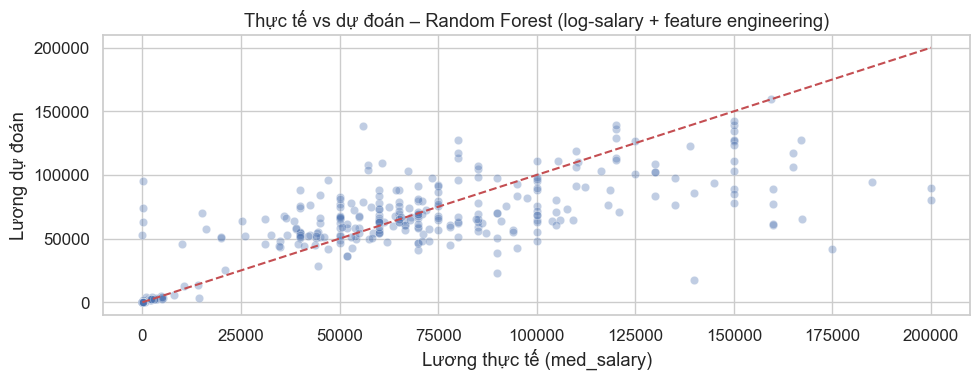

In [66]:
plt.figure(figsize=(10, 4))
sns.scatterplot(x=y_true, y=y_pred, alpha=0.35)

max_val = max(y_true.max(), y_pred.max())
plt.plot([0, max_val], [0, max_val], "r--", linewidth=1.5)

plt.xlabel("Lương thực tế (med_salary)")
plt.ylabel("Lương dự đoán")
plt.title("Thực tế vs dự đoán – Random Forest (log-salary + feature engineering)")
plt.tight_layout()
plt.show()


In [67]:
from sklearn.inspection import permutation_importance
import numpy as np

result = permutation_importance(
    model, X_test, y_test,
    n_repeats=10,
    random_state=42,
    n_jobs=-1
)

importances = result.importances_mean
feat_names = numeric_features + categorical_features

imp_df = pd.DataFrame(
    {"feature": feat_names, "importance": importances}
).sort_values("importance", ascending=False)

imp_df.head(15)


c:\Program Files\Python314\Lib\site-packages\sklearn\impute\_base.py:653: UserWarning: Skipping features without any observed values: ['min_salary' 'max_salary']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(


,feature,importance
18,pay_period,1.862917
15,formatted_experience_level,0.002858
5,follower_count,0.002252
14,city,0.001757
17,work_type,0.001660
16,formatted_work_type,0.001519
4,employee_count,0.001407
8,num_linkedin_skills,0.001395
6,desc_len,0.001233
13,state,0.001043
